<a href="https://colab.research.google.com/github/Adithyasajeev22/EDA-ML-DL-Projects/blob/main/AI_BASED_STUDENT_PERFORMANCE_PREDICTION__SYSTEM_(PROJECT_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEM STATEMENT**

Educational institutions struggle to identify students who are at risk of poor academic performance early. This project predicts student performance using historical academic and behavioural data to support timely intervention.

# **EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv('/content/Student_Performance_100K_20Columns.csv')
df.head(3)

,Student_ID,Gender,Age,Attendance_Percentage,Internal_Assessment_Marks,Midterm_Exam_Marks,Assignment_Score,Previous_Semester_Grade,Study_Hours_Per_Day,Participation_In_Activities,Internet_Access,Parent_Education_Level,Family_Income_Level,Socio_Economic_Status,Sleep_Hours,Screen_Time_Hours,Distance_From_College_KM,Class_Participation_Score,Scholarship_Status,Performance_Category
0,S000001,Male,22,90.8,49.6,91.9,56.8,A,4.1,High,Yes,School,Low,Low,6.6,3.9,16.1,96.8,No,Good
1,S000002,Female,24,62.3,66.8,65.9,57.4,C,3.6,High,Yes,Diploma,Low,Low,4.8,5.4,7.9,73.0,No,Good
2,S000003,Female,21,84.7,45.4,61.1,80.8,A,0.0,High,No,Graduate,Middle,Middle,8.7,1.9,19.8,74.8,No,Good


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  object 
 1   Gender                       100000 non-null  object 
 2   Age                          100000 non-null  int64  
 3   Attendance_Percentage        100000 non-null  float64
 4   Internal_Assessment_Marks    100000 non-null  float64
 5   Midterm_Exam_Marks           100000 non-null  float64
 6   Assignment_Score             100000 non-null  float64
 7   Previous_Semester_Grade      100000 non-null  object 
 8   Study_Hours_Per_Day          100000 non-null  float64
 9   Participation_In_Activities  100000 non-null  object 
 10  Internet_Access              100000 non-null  object 
 11  Parent_Education_Level       100000 non-null  object 
 12  Family_Income_Level          100000 non-null  object 
 13  

In [ ]:
df.columns

Index(['Student_ID', 'Gender', 'Age', 'Attendance_Percentage',
       'Internal_Assessment_Marks', 'Midterm_Exam_Marks', 'Assignment_Score',
       'Previous_Semester_Grade', 'Study_Hours_Per_Day',
       'Participation_In_Activities', 'Internet_Access',
       'Parent_Education_Level', 'Family_Income_Level',
       'Socio_Economic_Status', 'Sleep_Hours', 'Screen_Time_Hours',
       'Distance_From_College_KM', 'Class_Participation_Score',
       'Scholarship_Status', 'Performance_Category'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
Attendance_Percentage,0
Internal_Assessment_Marks,0
Midterm_Exam_Marks,0
Assignment_Score,0
Previous_Semester_Grade,0
Study_Hours_Per_Day,0
Participation_In_Activities,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
target='Performance_Category'

In [ ]:
df[target].value_counts()

,count
Performance_Category,
Good,97352
Poor,2648


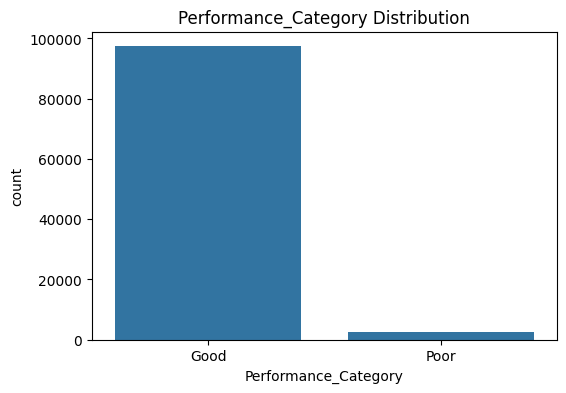

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=target,data=df)
plt.title("Performance_Category Distribution")
plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['Student_ID', 'Gender', 'Previous_Semester_Grade',
       'Participation_In_Activities', 'Internet_Access',
       'Parent_Education_Level', 'Family_Income_Level',
       'Socio_Economic_Status', 'Scholarship_Status', 'Performance_Category'],
      dtype='object')

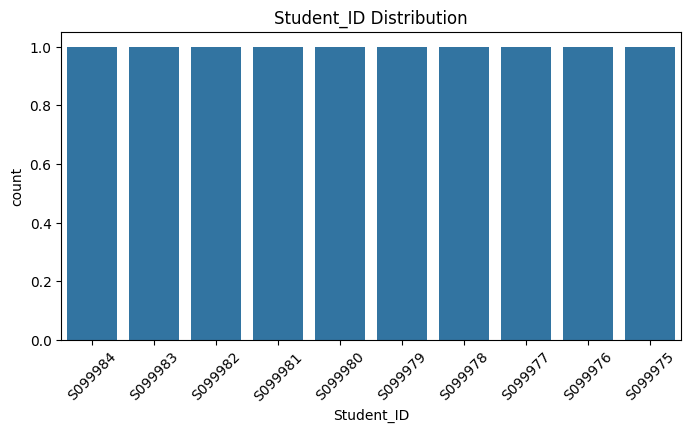

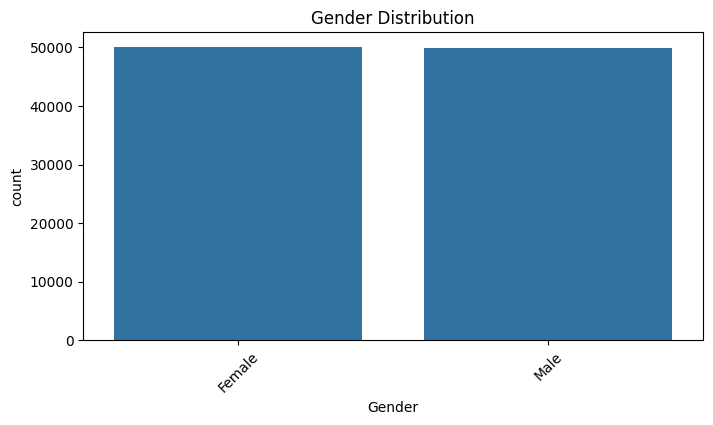

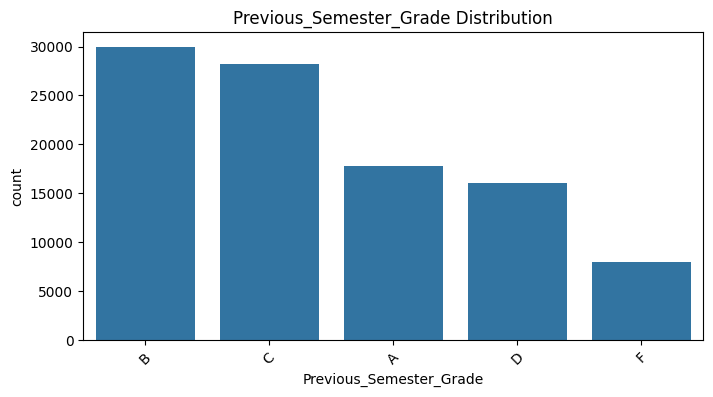

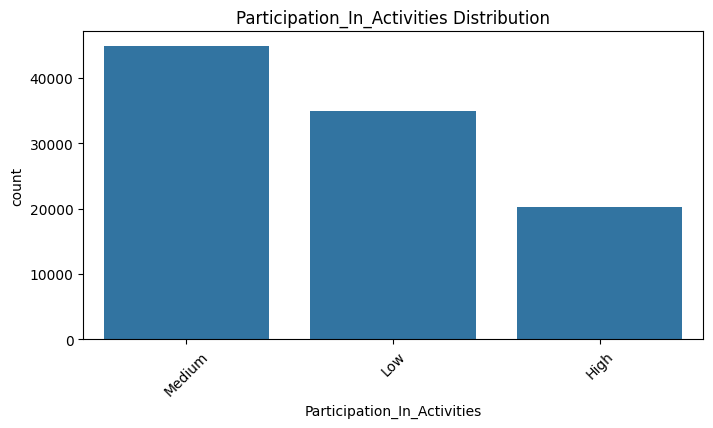

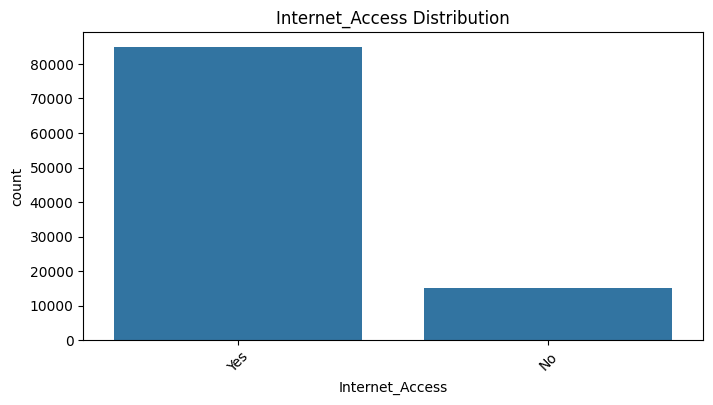

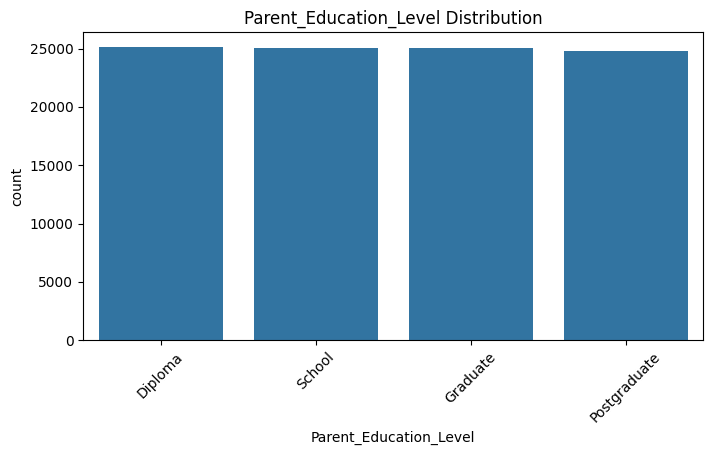

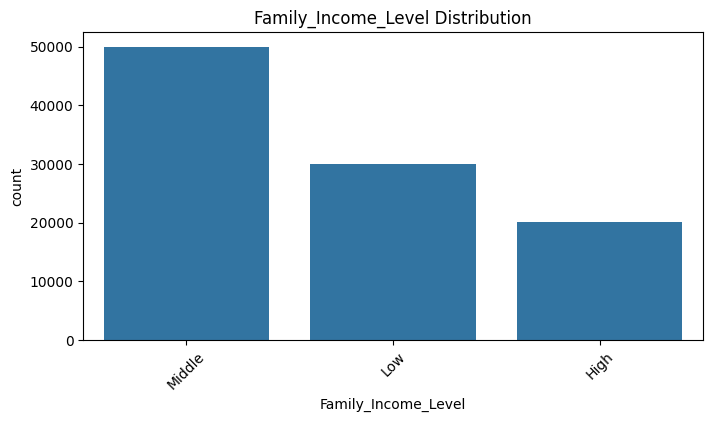

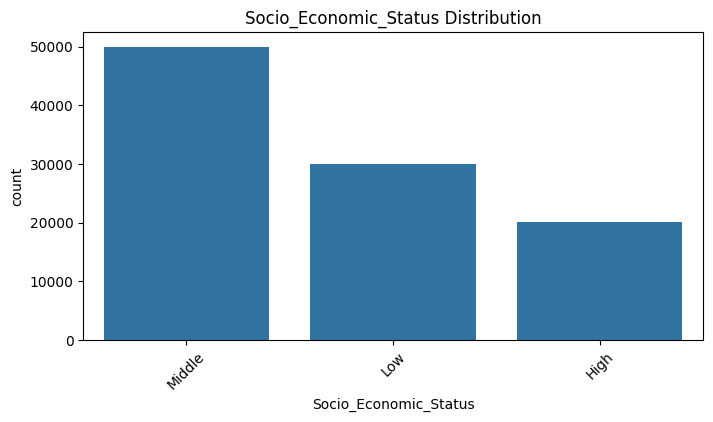

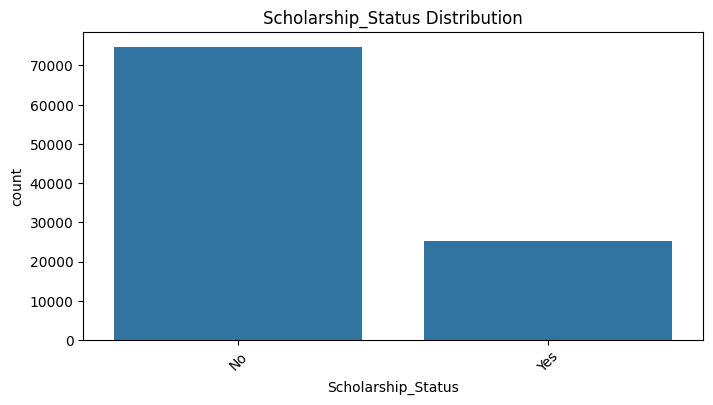

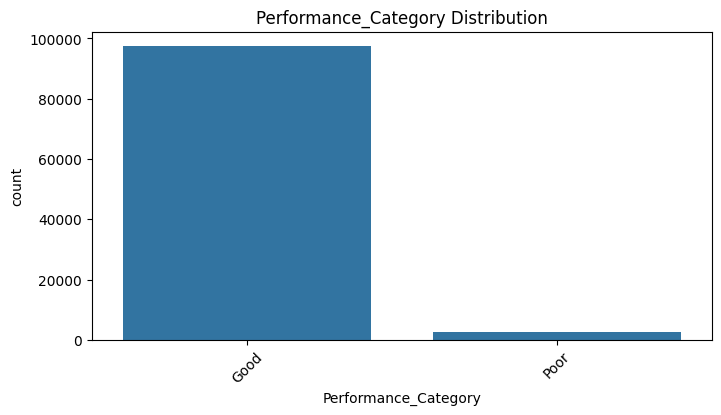

In [ ]:
for col in categorical_cols:
  plt.figure(figsize=(8,4))
  sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
  plt.xticks(rotation=45)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['Age', 'Attendance_Percentage', 'Internal_Assessment_Marks',
       'Midterm_Exam_Marks', 'Assignment_Score', 'Study_Hours_Per_Day',
       'Sleep_Hours', 'Screen_Time_Hours', 'Distance_From_College_KM',
       'Class_Participation_Score'],
      dtype='object')

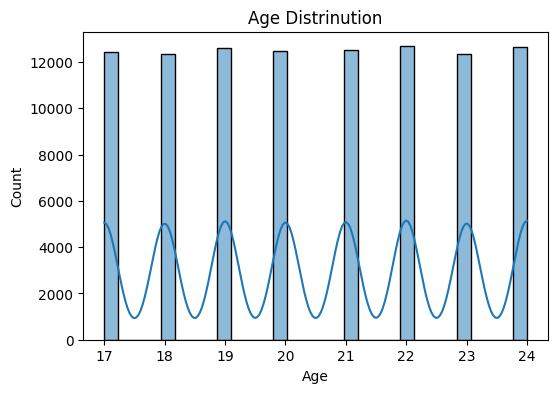

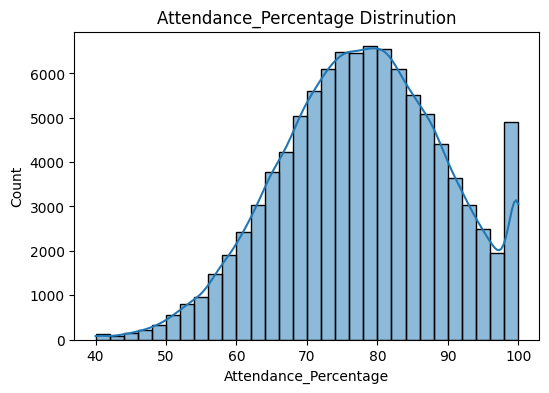

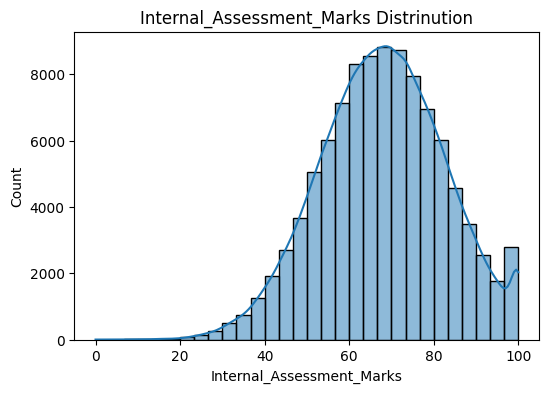

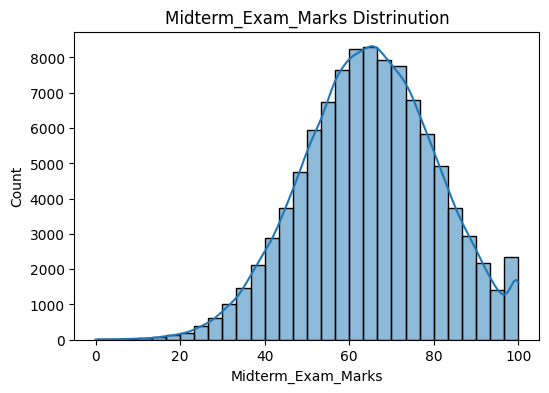

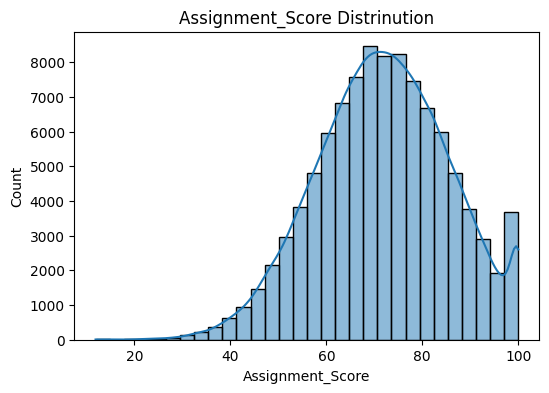

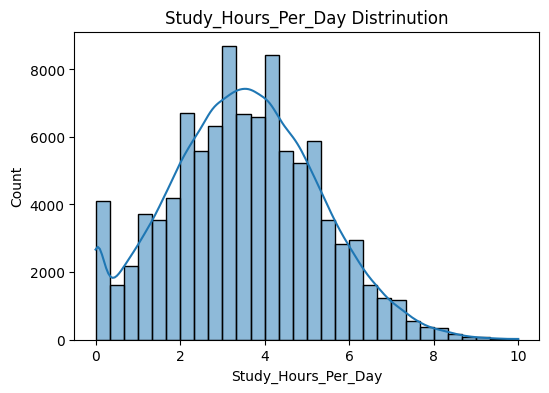

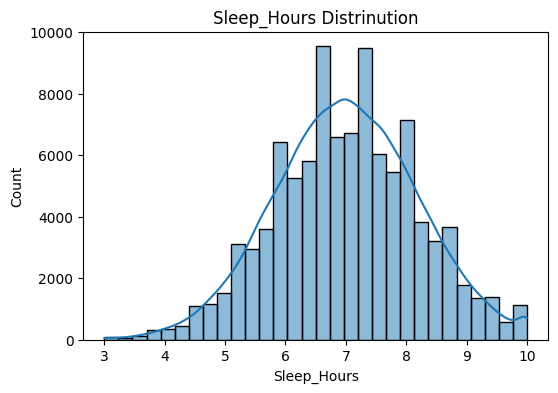

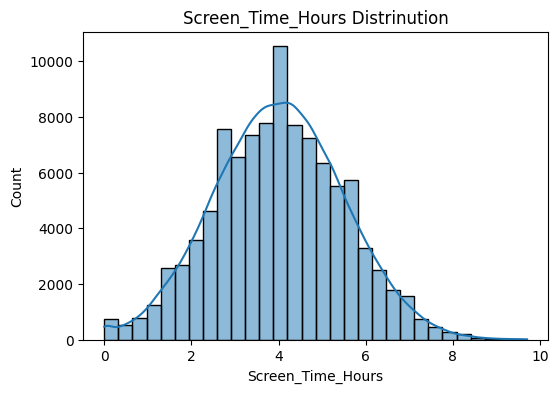

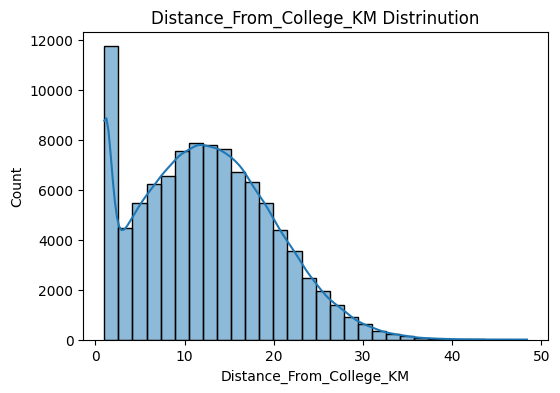

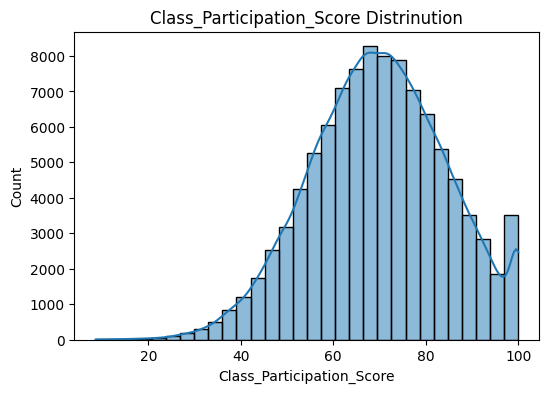

In [ ]:
for col in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],bins=30,kde=True)
  plt.title(f'{col} Distrinution')
  plt.show()

In [ ]:
categorical_cols

Index(['Student_ID', 'Gender', 'Previous_Semester_Grade',
       'Participation_In_Activities', 'Internet_Access',
       'Parent_Education_Level', 'Family_Income_Level',
       'Socio_Economic_Status', 'Scholarship_Status', 'Performance_Category'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['Student_ID']=le.fit_transform(df['Student_ID'])
df['Previous_Semester_Grade']=le.fit_transform(df['Previous_Semester_Grade'])
df['Participation_In_Activities']=le.fit_transform(df['Participation_In_Activities'])
df['Parent_Education_Level']=le.fit_transform(df['Parent_Education_Level'])
df['Family_Income_Level']=le.fit_transform(df['Family_Income_Level'])
df['Socio_Economic_Status']=le.fit_transform(df['Socio_Economic_Status'])

In [ ]:
print(df['Gender'].unique())

['Male' 'Female']


In [ ]:
print(df['Internet_Access'].unique())

['Yes' 'No']


In [ ]:
print(df['Scholarship_Status'].unique())

['No' 'Yes']


In [ ]:
print(df['Performance_Category'].unique())

['Good' 'Poor']


In [ ]:
df['Gender'].replace(['Male','Female'],[0,1],inplace=True)
df['Internet_Access'].replace(['Yes','No'],[0,1],inplace=True)
df['Scholarship_Status'].replace(['No','Yes'],[0,1],inplace=True)
df['Performance_Category'].replace(['Good','Poor'],[0,1],inplace=True)

/tmp/ipykernel_1320/1264296474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace(['Male','Female'],[0,1],inplace=True)
/tmp/ipykernel_1320/1264296474.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'].replace(['Male','Female'],[0,1],inplace=True)
/tmp/ipykernel_1

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  int64  
 1   Gender                       100000 non-null  int64  
 2   Age                          100000 non-null  int64  
 3   Attendance_Percentage        100000 non-null  float64
 4   Internal_Assessment_Marks    100000 non-null  float64
 5   Midterm_Exam_Marks           100000 non-null  float64
 6   Assignment_Score             100000 non-null  float64
 7   Previous_Semester_Grade      100000 non-null  int64  
 8   Study_Hours_Per_Day          100000 non-null  float64
 9   Participation_In_Activities  100000 non-null  int64  
 10  Internet_Access              100000 non-null  int64  
 11  Parent_Education_Level       100000 non-null  int64  
 12  Family_Income_Level          100000 non-null  int64  
 13  

In [ ]:
df.columns

Index(['Student_ID', 'Gender', 'Age', 'Attendance_Percentage',
       'Internal_Assessment_Marks', 'Midterm_Exam_Marks', 'Assignment_Score',
       'Previous_Semester_Grade', 'Study_Hours_Per_Day',
       'Participation_In_Activities', 'Internet_Access',
       'Parent_Education_Level', 'Family_Income_Level',
       'Socio_Economic_Status', 'Sleep_Hours', 'Screen_Time_Hours',
       'Distance_From_College_KM', 'Class_Participation_Score',
       'Scholarship_Status', 'Performance_Category'],
      dtype='object')

In [ ]:
#SMOTE (OVER SAMPLING) is used to clear inblance

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd



# Features and Target
x = df[['Student_ID', 'Gender', 'Age', 'Attendance_Percentage',
       'Internal_Assessment_Marks', 'Midterm_Exam_Marks', 'Assignment_Score',
       'Previous_Semester_Grade', 'Study_Hours_Per_Day',
       'Participation_In_Activities', 'Internet_Access',
       'Parent_Education_Level', 'Family_Income_Level',
       'Socio_Economic_Status', 'Sleep_Hours', 'Screen_Time_Hours',
       'Distance_From_College_KM', 'Class_Participation_Score',
       'Scholarship_Status']]
y = df['Performance_Category']

# Apply SMOTE
smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)

# Combine X and Y into one DataFrame
df_resampled = pd.concat(
    [pd.DataFrame(x_resampled, columns=x.columns),
     pd.DataFrame(y_resampled, columns=['Performance_Category'])],
    axis=1
)

# Display balanced dataset
print(df_resampled.head())

# Check class distribution
print(df_resampled['Performance_Category'].value_counts())

   Student_ID  Gender  Age  Attendance_Percentage  Internal_Assessment_Marks  \
0           0       0   22                   90.8                       49.6   
1           1       1   24                   62.3                       66.8   
2           2       1   21                   84.7                       45.4   
3           3       0   20                   78.1                       73.5   
4           4       0   17                  100.0                       62.0   

   Midterm_Exam_Marks  Assignment_Score  Previous_Semester_Grade  \
0                91.9              56.8                        0   
1                65.9              57.4                        2   
2                61.1              80.8                        0   
3                65.5              78.7                        0   
4                54.6              81.6                        0   

   Study_Hours_Per_Day  Participation_In_Activities  Internet_Access  \
0                  4.1                

In [ ]:
df=df_resampled

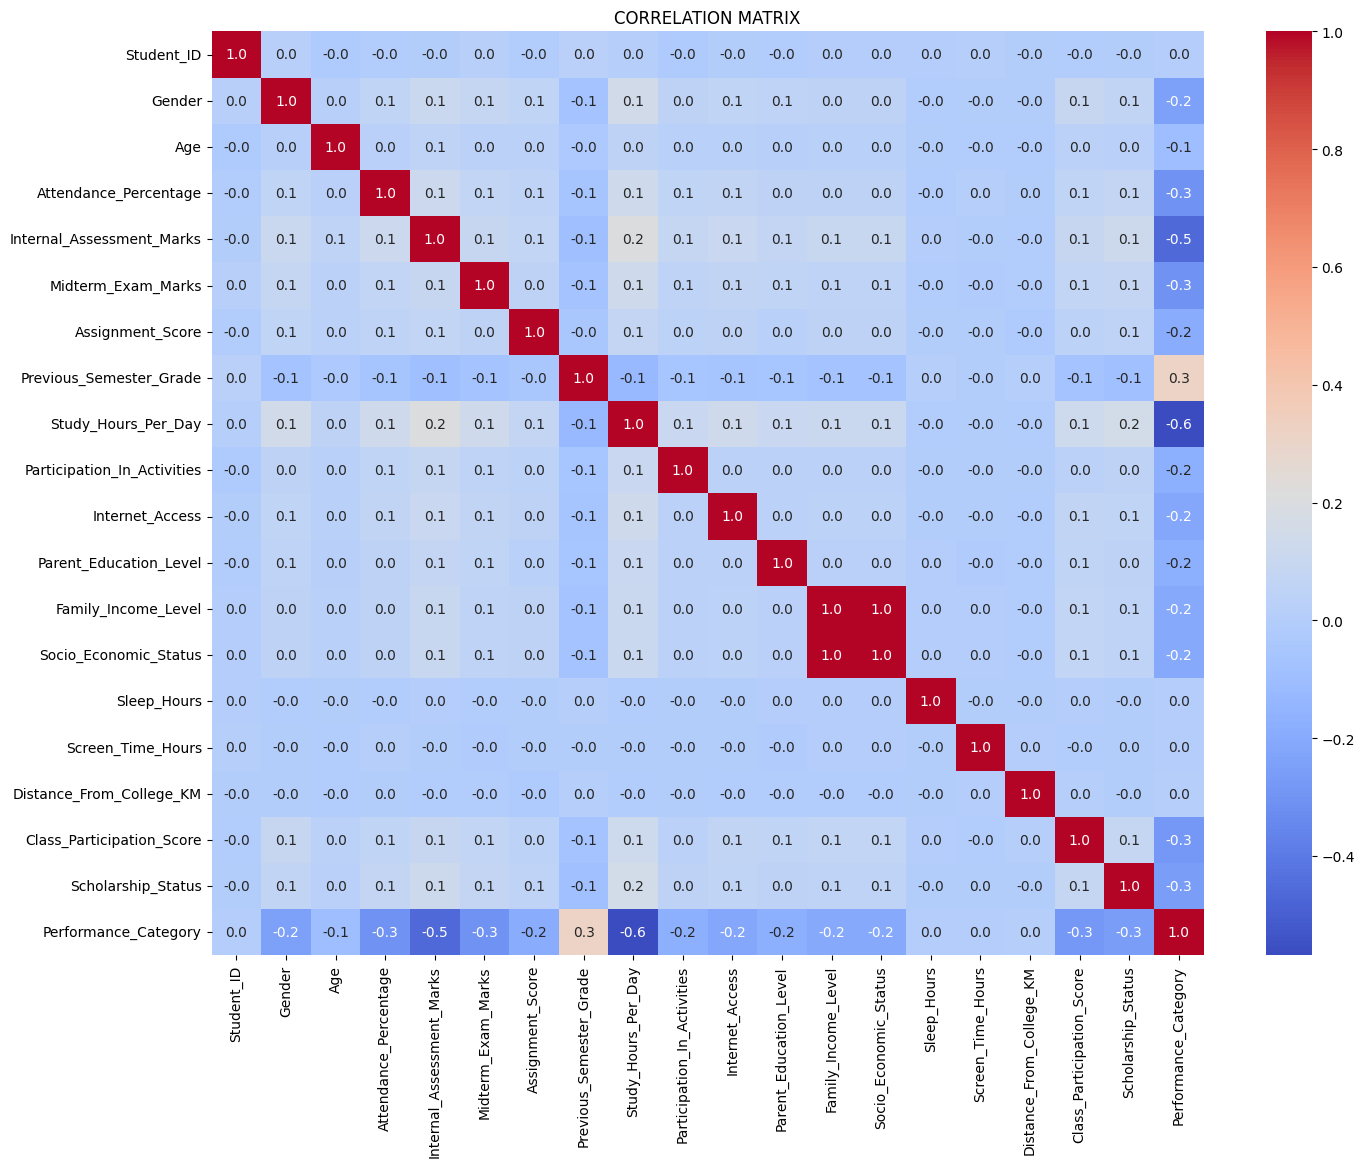

In [ ]:
corr_matrix=df.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('CORRELATION MATRIX')
plt.show()

In [ ]:
df.drop(['Socio_Economic_Status'],inplace=True,axis=1)

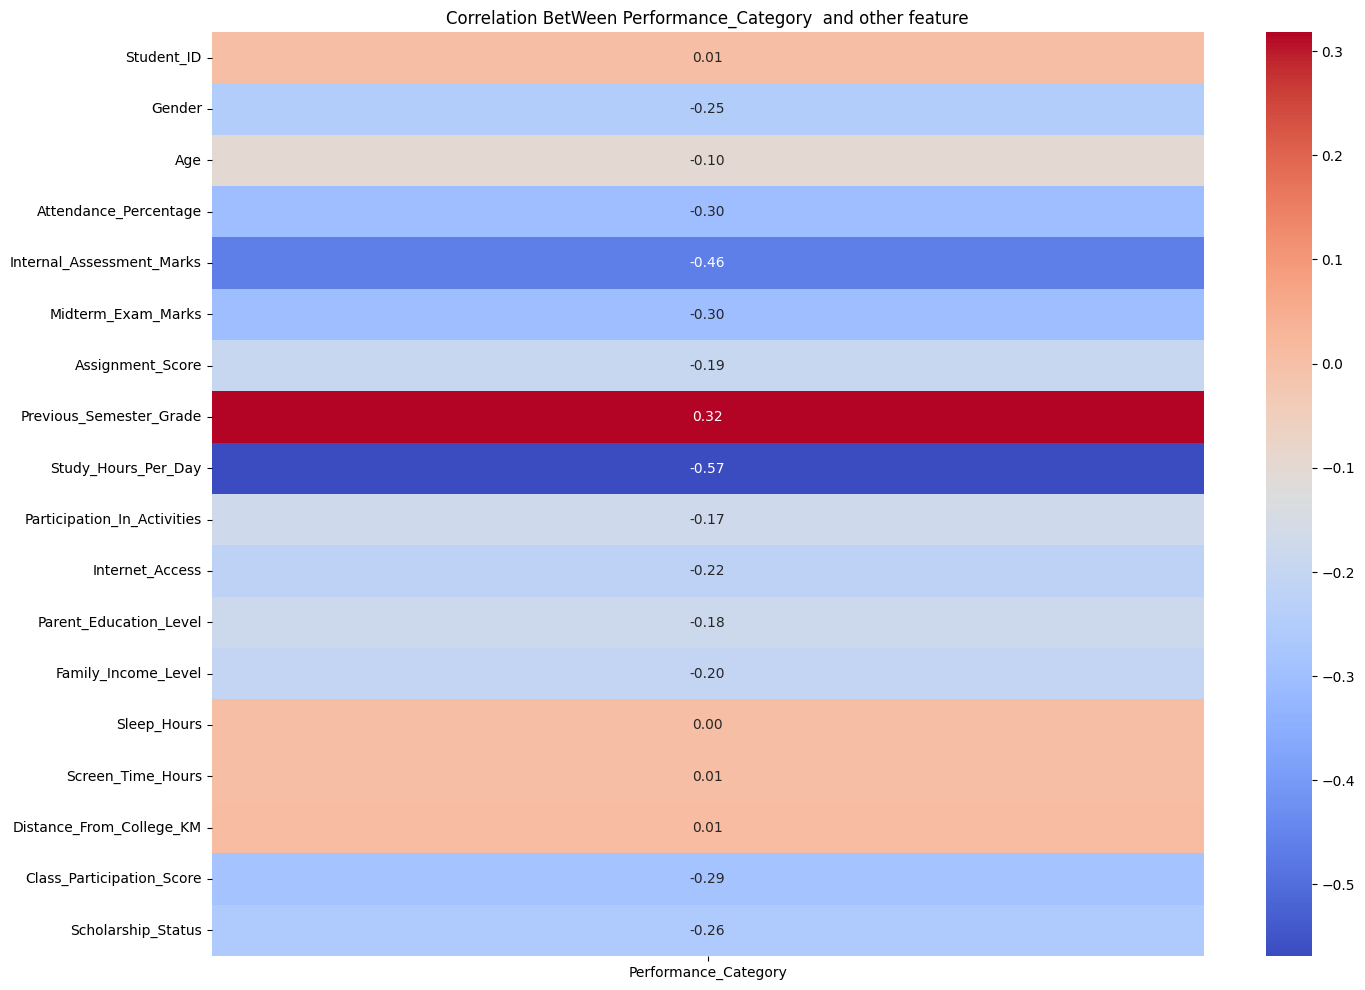

In [ ]:
status_corr=df.corr()['Performance_Category']
status_corr=status_corr.drop('Performance_Category')
plt.figure(figsize=(16,12))
sns.heatmap(status_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title('Correlation BetWeen Performance_Category  and other feature')
plt.show()

In [ ]:
df.columns

Index(['Student_ID', 'Gender', 'Age', 'Attendance_Percentage',
       'Internal_Assessment_Marks', 'Midterm_Exam_Marks', 'Assignment_Score',
       'Previous_Semester_Grade', 'Study_Hours_Per_Day',
       'Participation_In_Activities', 'Internet_Access',
       'Parent_Education_Level', 'Family_Income_Level', 'Sleep_Hours',
       'Screen_Time_Hours', 'Distance_From_College_KM',
       'Class_Participation_Score', 'Scholarship_Status',
       'Performance_Category'],
      dtype='object')

In [ ]:
df.drop(['Study_Hours_Per_Day','Sleep_Hours','Class_Participation_Score'],inplace=True,axis=1)

In [ ]:
df.shape

(194704, 16)

<Axes: >

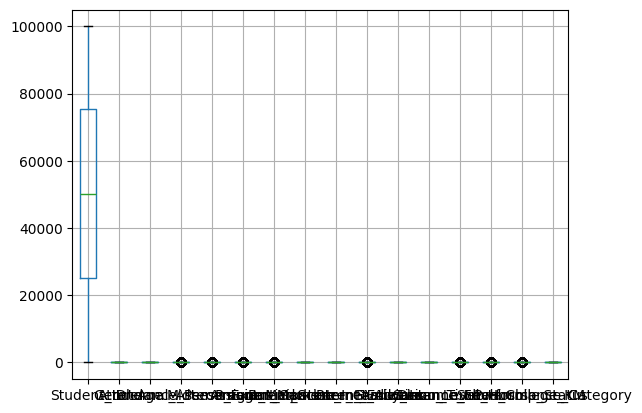

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr

    df=df[(df[col] >=lower_bound)& (df[col] <=upper_bound)]
  return df

df_cleaned=remove_outliers_iqr(df,exclude_column='Performance_Category')
df=df_cleaned

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['Student_ID', 'Gender', 'Age', 'Attendance_Percentage',
       'Internal_Assessment_Marks', 'Midterm_Exam_Marks', 'Assignment_Score',
       'Previous_Semester_Grade',
       'Participation_In_Activities', 'Internet_Access',
       'Parent_Education_Level', 'Family_Income_Level',
       'Screen_Time_Hours', 'Distance_From_College_KM',
        'Scholarship_Status']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

# **MACHINE LEARNING**

In [ ]:
# LOGISTIC REGRESSION

x=df[['Student_ID', 'Gender', 'Age', 'Attendance_Percentage',
       'Internal_Assessment_Marks', 'Midterm_Exam_Marks', 'Assignment_Score',
       'Previous_Semester_Grade',
       'Participation_In_Activities', 'Internet_Access',
       'Parent_Education_Level', 'Family_Income_Level',
       'Screen_Time_Hours', 'Distance_From_College_KM',
        'Scholarship_Status']]
y=df['Performance_Category']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline Model Accuracy:{accuracy:.2f}')

Baseline Model Accuracy:0.74


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# DECISION TREE

from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline Model Accuracy:{accuracy:.2f}')

Baseline Model Accuracy:0.91


In [ ]:
# SVC

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# pipeline
model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

# Train
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Pipeline Linear SVC Accuracy: {accuracy:.2f}")

Pipeline Linear SVC Accuracy: 0.85


In [ ]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=model.score(x_test,y_test)
print(f'Baseline model accuracy:{accuracy:.2f}')

Baseline model accuracy:0.95


In [ ]:
# GRADIENTBOOSTER

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

print("Gradient Boosting Accuracy:",accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8891331487814146


In [ ]:
# ADA BOOST

from sklearn.ensemble import AdaBoostClassifier

model=AdaBoostClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"AdaBoost model accuracy: {accuracy:.2f}")

AdaBoost model accuracy: 0.86


In [ ]:
# XGBOOST

from  xgboost import XGBClassifier

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=XGBClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"xgboost model accuracy: {accuracy:.2f}")

xgboost model accuracy: 0.95


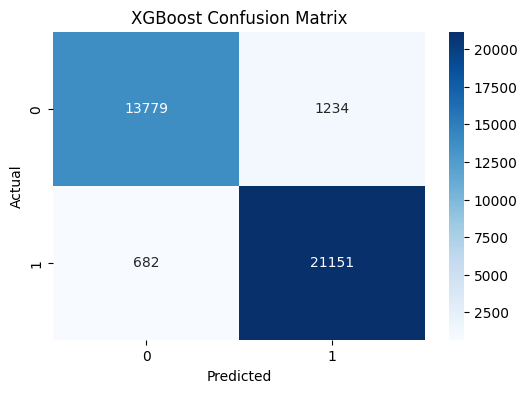

In [ ]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

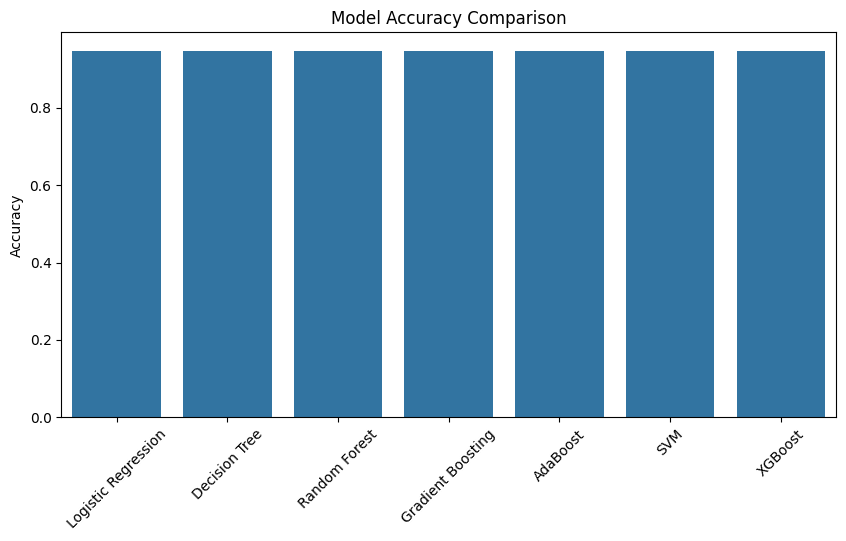

In [ ]:
models=[
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'AdaBoost',
    'SVM',
    'XGBoost']

accuracies=[
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred)]

plt.figure(figsize=(10,5))

sns.barplot(x=models,y=accuracies)

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

# **K-FOLD CROSS VALIDATION**

In [ ]:
x=df.drop('Performance_Category',axis=1)
y=df['Performance_Category']

kf=KFold(n_splits=5,shuffle=True,random_state=42)

model=LogisticRegression(max_iter=10000)

best_accuracy=0
best_fold=-1

best_x_train=None
best_y_train=None
best_x_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):

    print(f"\nFold {fold}")

    x_train,x_test=x.iloc[train_index],x.iloc[test_index]
    y_train,y_test=y.iloc[train_index],y.iloc[test_index]

    model.fit(x_train,y_train)

    y_pred=model.predict(x_test)

    acc=accuracy_score(y_test,y_pred)

    print("Accuracy:",acc)

    if acc>best_accuracy:

        best_accuracy=acc
        best_fold=fold

        best_x_train=x_train
        best_y_train=y_train

        best_x_test=x_test
        best_y_test=y_test

        best_y_pred=y_pred

print(f"\nBest Fold: {best_fold} with Accuracy: {best_accuracy}")


Fold 1


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8498151100858297

Fold 2


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8446246225871018

Fold 3


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8500865081249788

Fold 4


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8455014248880445

Fold 5
Accuracy: 0.8475709051431674

Best Fold: 3 with Accuracy: 0.8500865081249788


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model=LogisticRegression(max_iter=10000)
model.fit(best_x_train,best_y_train)
print("Logistic Regression:",model.score(best_x_test,best_y_test))

Logistic Regression: 0.8500865081249788


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
print("Random Forest:",model.score(best_x_test,best_y_test))

Random Forest: 0.9511822777080435


In [ ]:
model=DecisionTreeClassifier(random_state=42)
model.fit(best_x_train,best_y_train)
print("Decision Tree:",model.score(best_x_test,best_y_test))

Decision Tree: 0.9046375139939614


In [ ]:
model=SVC()
model.fit(best_x_train,best_y_train)
print("SVM:",model.score(best_x_test,best_y_test))

SVM: 0.5926993927468874


In [ ]:
model=GradientBoostingClassifier(random_state=42)
model.fit(best_x_train,best_y_train)
print("Gradient Boosting:",model.score(best_x_test,best_y_test))

Gradient Boosting: 0.8881840078705432


In [ ]:
model=AdaBoostClassifier(random_state=42)
model.fit(best_x_train,best_y_train)
print("AdaBoost:",model.score(best_x_test,best_y_test))

AdaBoost: 0.8630796892492452


In [ ]:
model=XGBClassifier(eval_metric='logloss',random_state=42)
model.fit(best_x_train,best_y_train)
print("XGBoost:",model.score(best_x_test,best_y_test))

XGBoost: 0.9469756081012315


# **DEEP LEARNING**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


model=Sequential()
model.add(Dense(128,input_shape=(x.shape[1],),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(50,activation='relu'))
model.add(Dense(46,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


model.compile(optimizer=Adam(),loss='binary_crossentropy',metrics=['accuracy'])

model.fit(best_x_train,best_y_train,epochs=200)

y_pred=model.predict(best_x_test)
y_pred=(y_pred>0.5).astype(int)

print(f'\nAccuracy: {accuracy_score(best_y_test,y_pred)}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
3685/3685 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.5261 - loss: 6.3836
Epoch 2/200
3685/3685 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.5564 - loss: 1.1101
Epoch 3/200
3685/3685 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5948 - loss: 0.6754
Epoch 4/200
3685/3685 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.5944 - loss: 0.6880
Epoch 5/200
3685/3685 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.5939 - loss: 0.6774
Epoch 6/200
3685/3685 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.5934 - loss: 0.6859
Epoch 7/200
3685/3685 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.5940 - loss: 0.6751
Epoch 8/200
3685/3685 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5943 - loss: 0.6761
Epoch 9/200
3685/3685 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.5942 - loss: 0.6754
Epoch 10/200
3685/3685 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5943 - loss: 0.6760
Epoch 11/200
3685/3685 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5943 - loss: 0.6823
Epoch 12/200

# **CONCLUSION**

This project developed an AI-based Student Performance Prediction System using the Student Performance dataset and various machine learning algorithms to predict students' performance categories based on academic, demographic, and lifestyle factors. Exploratory Data Analysis (EDA) and data preprocessing techniques were performed to understand the dataset and identify the factors influencing student performance.

Among all the models, Random Forest achieved the highest accuracy of 95.12%, followed closely by XGBoost with an accuracy of 94.70%. Decision Tree, Gradient Boosting, AdaBoost, and Logistic Regression also produced good results, while SVM showed comparatively lower performance with an accuracy of 59.27%. The results indicate that ensemble learning methods are highly effective in predicting student performance and can be used to support educational decision-making and early intervention strategies.

# **FUTURE SCOPE**

In the future, this project can be enhanced by incorporating larger and more diverse educational datasets from different schools and universities to improve model generalization. Additional features such as extracurricular activities, psychological factors, learning styles, and real-time academic records can also be included to increase prediction accuracy.

The system can further be integrated into a web or mobile application that provides real-time student performance predictions and identifies students who may require academic support. Advanced deep learning techniques and explainable AI methods can also be implemented to improve prediction performance and help educators understand the key factors affecting student success.